# 01 · EDA and Data Preparation — Beijing PM2.5 (one-hour-ahead forecasting)

**Pipeline:** `01_EDA.ipynb` → `02_Baseline_Models.ipynb` → `03_ANN_Model.ipynb`

This notebook (1) explores the data (EDA carried over from `main.ipynb`), then (2) builds the **leakage-safe** feature set and the **chronological train / validation / test split** that *both* the baseline and the ANN notebooks load. Using one saved split guarantees every model is scored on identical rows.

**Task:** at hour *t-1*, predict PM2.5 at hour *t*.

| Split | Period | Use |
|---|---|---|
| Train | 2010 – 2012 | fit models / scalers |
| Validation | 2013 | early stopping, model selection |
| Test | 2014 | final, one-time evaluation |

**Leakage fixes versus `main.ipynb`** (details in section 5):
1. Missing PM2.5 is imputed with a *causal* forward-fill. `interpolate(limit_direction='both')` used future values.
2. Weather columns (DEWP, TEMP, PRES, Iws, Is, Ir, cbwd) are shifted by one hour. At forecast time *t-1* the weather at *t* is not known.
3. Early stopping uses a separate validation year. `main.ipynb` early-stopped on the test set.
4. `year` is dropped as a feature (the test year is outside the training range).
5. Scalers and encoders are fit on the training split only (done in notebooks 02 and 03).
6. Metrics are computed only on hours where PM2.5 was actually measured, not on imputed hours.

## 1. Import Libraries

In [16]:
import json, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH = 'beijing_dataset.csv'   # same file used in main.ipynb
OUT_DIR   = 'data'                  # train/val/test CSVs are written here
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load and Basic Cleaning

In [17]:
df = pd.read_csv(DATA_PATH)
pd.set_option('display.max_columns', None)
df.drop(columns='No', inplace=True)
df = df.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.head()

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
0,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


In [18]:
print('Shape:', df.shape)
print(f"Year range  {df['year'].min()} - {df['year'].max()}")
print(f"Month range {df['month'].min()} - {df['month'].max()}")
print(f"Day range   {df['day'].min()} - {df['day'].max()}")
print(f"Hour range  {df['hour'].min()} - {df['hour'].max()}")

# The whole pipeline (lags, 24h seasonal naive) assumes a gap-free hourly index.
steps = df['datetime'].diff().dropna().value_counts()
print('\nTime steps between consecutive rows:\n', steps)
assert df['datetime'].is_unique and (steps.index == pd.Timedelta(hours=1)).all(), 'index is not strictly hourly'

Shape: (43824, 13)
Year range  2010 - 2014
Month range 1 - 12
Day range   1 - 31
Hour range  0 - 23

Time steps between consecutive rows:
 datetime
0 days 01:00:00    43823
Name: count, dtype: int64


## 3. Exploratory Data Analysis

EDA is descriptive only. Nothing computed here (means, correlations) feeds into the models, so it cannot leak. PM2.5 is left **un-imputed** for these plots; missing hours are simply ignored.

In [19]:
miss = df.isnull().sum()
print(miss)
print(f"\nMissing PM2.5: {df['pm2.5'].isna().sum()} hours ({df['pm2.5'].isna().mean():.1%})")

year           0
month          0
day            0
hour           0
pm2.5       2067
DEWP           0
TEMP           0
PRES           0
cbwd           0
Iws            0
Is             0
Ir             0
datetime       0
dtype: int64

Missing PM2.5: 2067 hours (4.7%)


### 3.1 PM2.5 Distribution

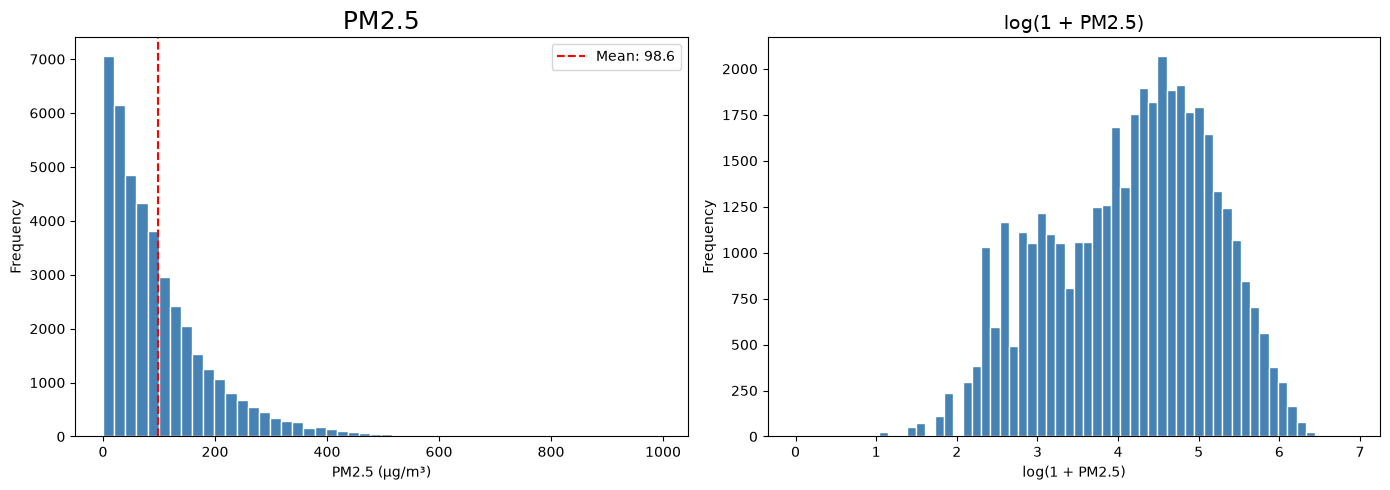

Skewness (raw):        1.802
Skewness (log1p):      -0.304


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['pm2.5'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5', fontsize=18)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['pm2.5'].mean(), color='red', linestyle='--', label=f"Mean: {df['pm2.5'].mean():.1f}")
axes[0].legend()

axes[1].hist(np.log1p(df['pm2.5'].dropna()), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('log(1 + PM2.5)', fontsize=14)
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {stats.skew(df['pm2.5'].dropna()):.3f}")
print(f"Skewness (log1p):      {stats.skew(np.log1p(df['pm2.5'].dropna())):.3f}")

### 3.2 Correlation Heatmap

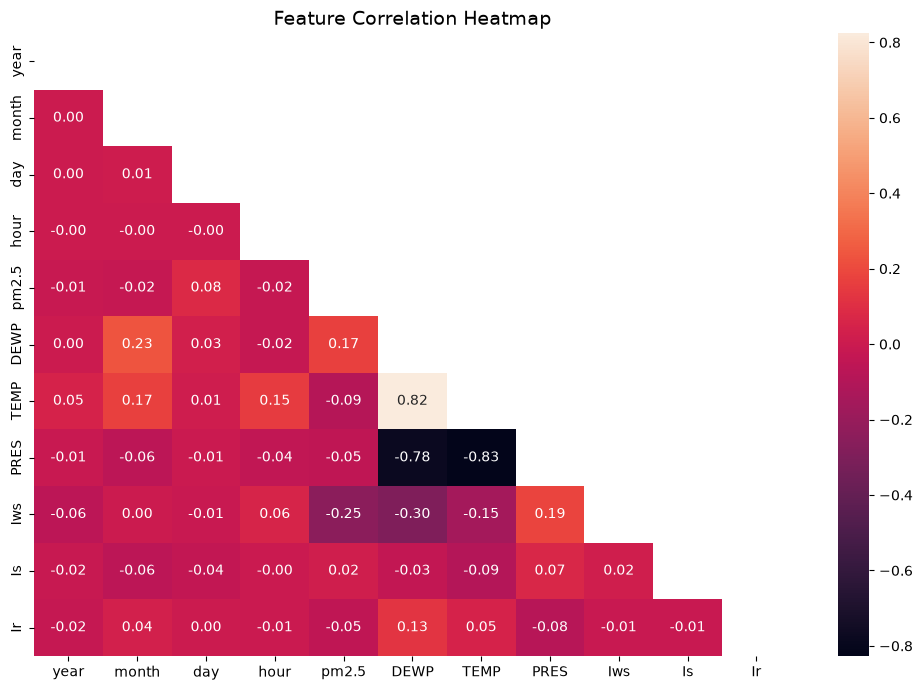

Top correlations with PM2.5
Iws      0.247784
DEWP     0.171423
TEMP     0.090534
day      0.082788
Ir       0.051369
PRES     0.047282
month    0.024069
hour     0.023116
Is       0.019266
year     0.014690


In [21]:
plt.figure(figsize=(10, 7))
corr = df.drop(columns='datetime').select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('Top correlations with PM2.5')
print(corr['pm2.5'].drop('pm2.5').abs().sort_values(ascending=False).to_string())

### 3.3 Temporal Patterns

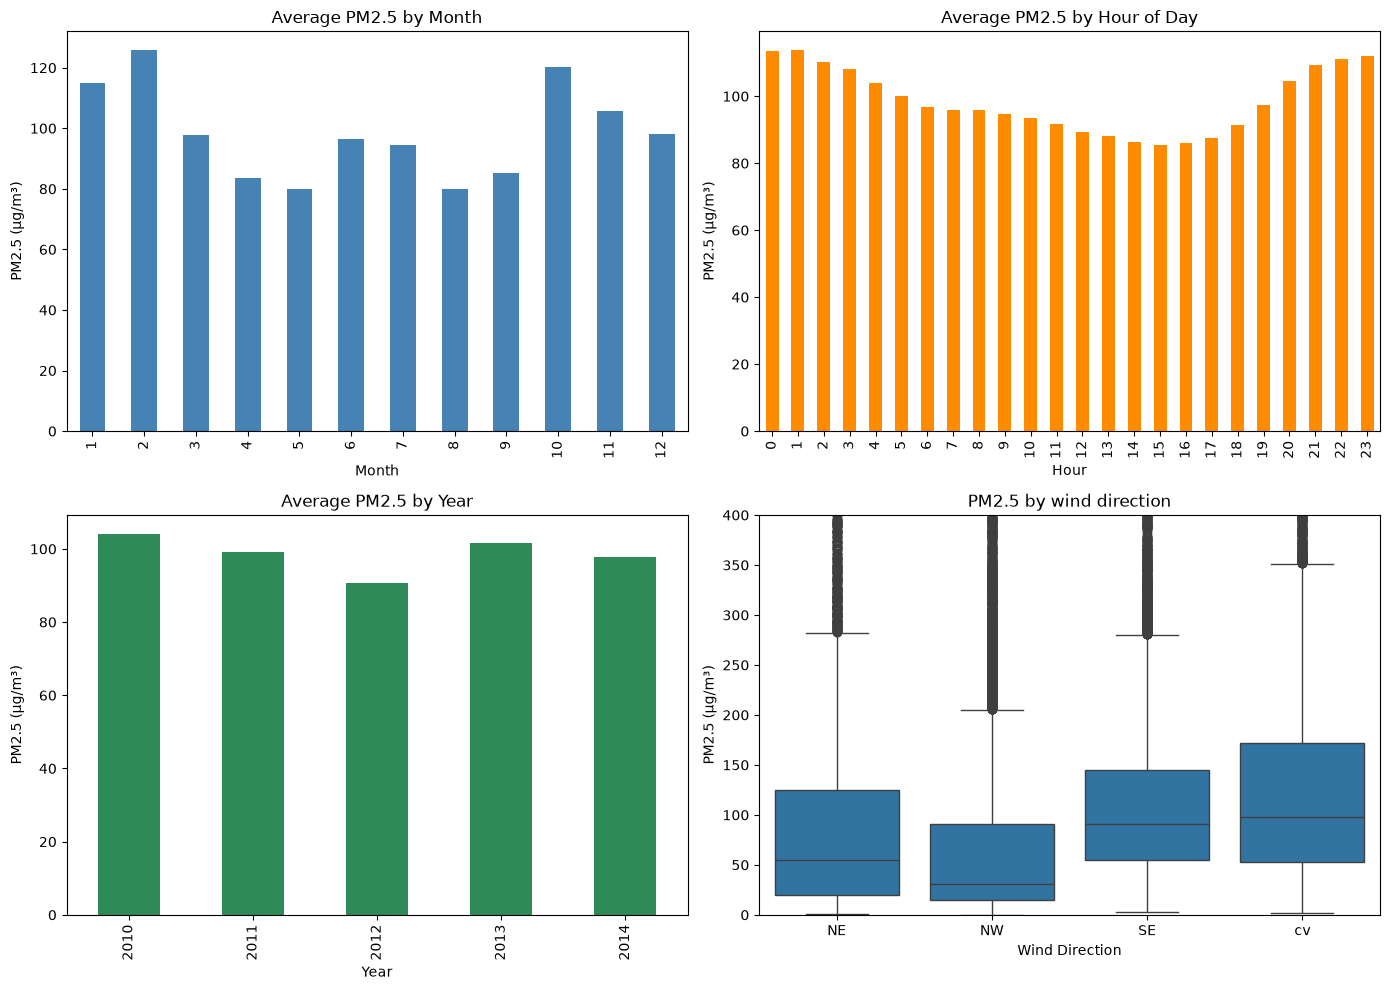

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('month')['pm2.5'].mean().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (µg/m³)')

df.groupby('hour')['pm2.5'].mean().plot(kind='bar', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Average PM2.5 by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('PM2.5 (µg/m³)')

df.groupby('year')['pm2.5'].mean().plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Average PM2.5 by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')

sns.boxplot(x=df['cbwd'], y=df['pm2.5'], ax=axes[1, 1], order=['NE', 'NW', 'SE', 'cv'])
axes[1, 1].set_title('PM2.5 by wind direction')
axes[1, 1].set_xlabel('Wind Direction')
axes[1, 1].set_ylabel('PM2.5 (µg/m³)')
axes[1, 1].set_ylim(0, 400)

plt.tight_layout()
plt.show()

### 3.4 Meteorological Feature Relationship

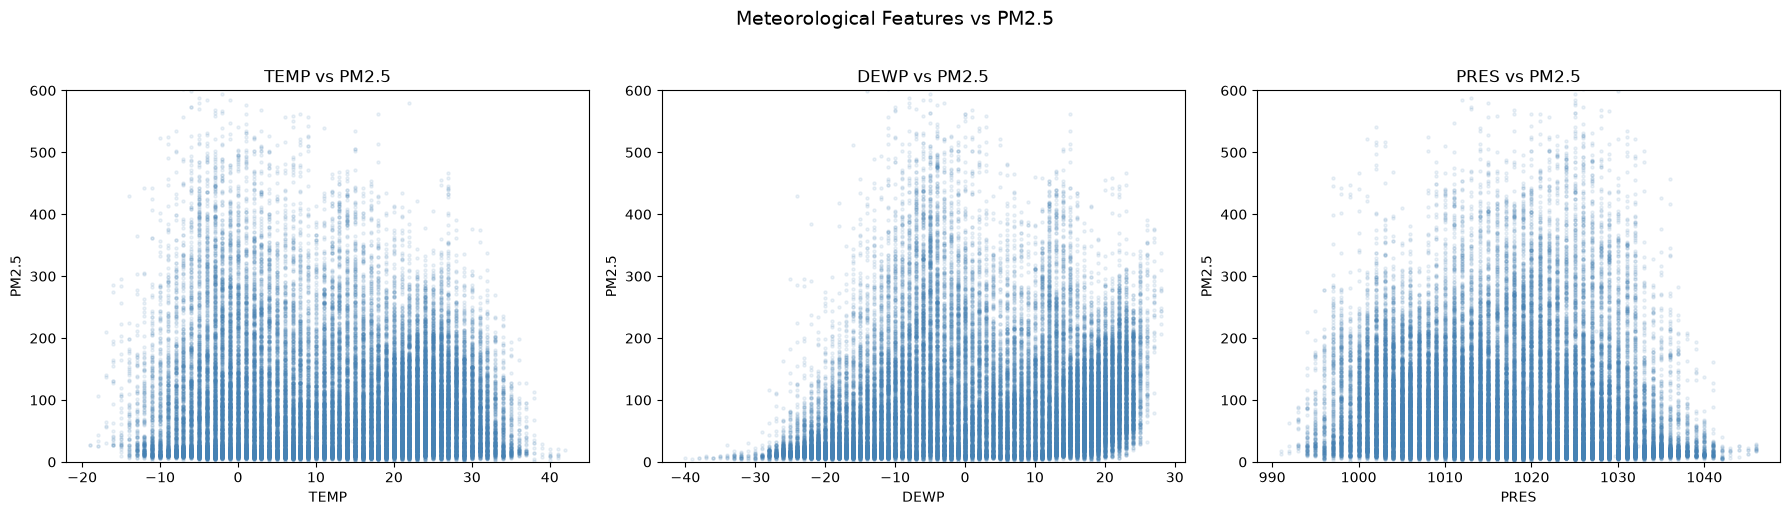

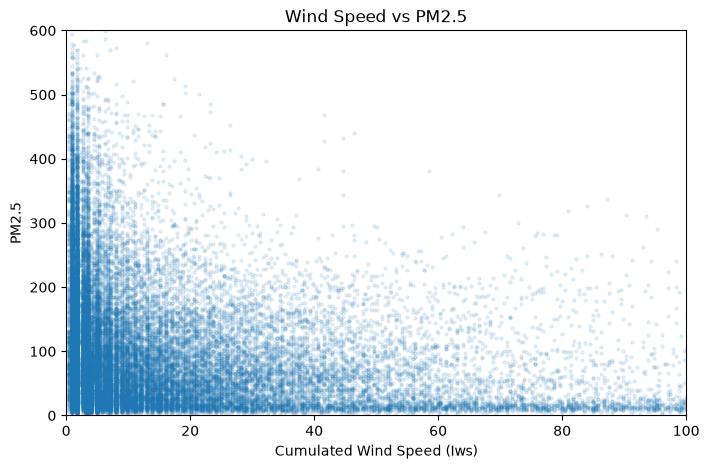

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['TEMP', 'DEWP', 'PRES']):
    ax.scatter(df[col], df['pm2.5'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('PM2.5')
    ax.set_title(f'{col} vs PM2.5')
    ax.set_ylim(0, 600)
plt.suptitle('Meteorological Features vs PM2.5', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Iws'], df['pm2.5'], alpha=0.1, s=5)
plt.xlabel('Cumulated Wind Speed (Iws)')
plt.ylabel('PM2.5')
plt.title('Wind Speed vs PM2.5')
plt.ylim(0, 600)
plt.xlim(0, 100)
plt.show()

### 3.5 Temporal Autocorrelation

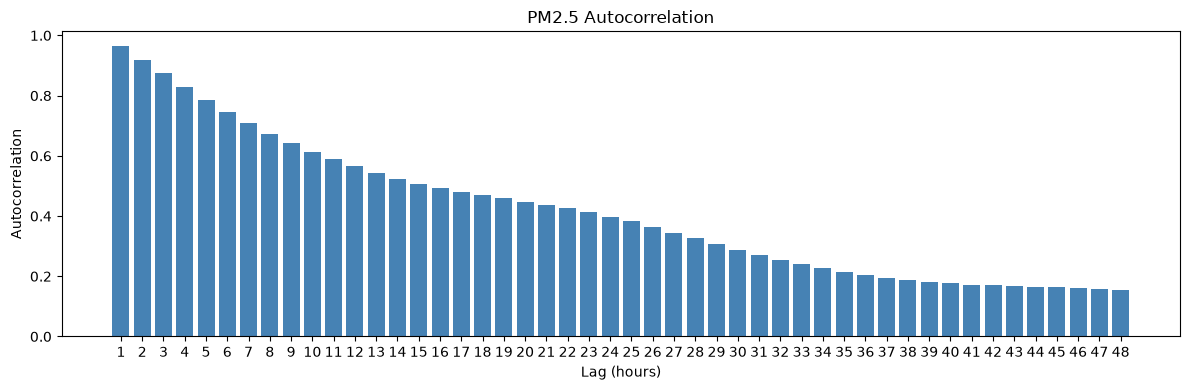

Autocorrelation at lag-1:  0.965
Autocorrelation at lag-2:  0.920
Autocorrelation at lag-24: 0.398

A lag-1 autocorrelation this high is why Persistence will be a very strong baseline.


In [24]:
lags = range(1, 49)
autocorr = [df['pm2.5'].autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 4))
plt.bar(lags, autocorr, color='steelblue')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Lag (hours)')
plt.ylabel('Autocorrelation')
plt.title('PM2.5 Autocorrelation')
plt.xticks(list(range(1, 49, 1)))
plt.tight_layout()
plt.show()

print(f"Autocorrelation at lag-1:  {df['pm2.5'].autocorr(1):.3f}")
print(f"Autocorrelation at lag-2:  {df['pm2.5'].autocorr(2):.3f}")
print(f"Autocorrelation at lag-24: {df['pm2.5'].autocorr(24):.3f}")
print('\nA lag-1 autocorrelation this high is why Persistence will be a very strong baseline.')

## 4. Causal imputation of missing PM2.5

`main.ipynb` used `interpolate(limit_direction='both')`, which fills a gap using the value *after* it, and so leaks future information into the past. Here we use a **forward-fill**, which uses only past observations. The original observed/missing status is kept in `target_observed`, so evaluation can be restricted to genuinely measured hours.

In [25]:
df['target_observed'] = df['pm2.5'].notna()
df['pm2.5'] = df['pm2.5'].ffill()      # causal: only past values; leading NaNs are dropped later
print('Leading NaNs left after ffill:', df['pm2.5'].isna().sum())

Leading NaNs left after ffill: 24


## 5. Feature Engineering (leakage-safe, one-hour-ahead)

Row *t* holds the **target** `pm2.5` at hour *t* and features that are all known at hour *t-1*:

* **PM2.5 history**: lags 1, 2, 3, 6, 12, 24 and rolling mean / std / EMA over 3, 6, 12, 24 h, all computed on `shift(1)`.
* **Weather**: DEWP, TEMP, PRES, Iws, Is, Ir, cbwd taken from hour *t-1* (`*_prev`).
* **Calendar of the target hour**: hour and month as sin/cos, plus day of month. The clock is known in advance, so this is not leakage.

In [26]:
weather_cols = ['DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
for c in weather_cols:
    df[f'{c}_prev'] = df[c].shift(1)          # weather as observed at the forecast origin (t-1)
df.drop(columns=weather_cols, inplace=True)

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

for lag in [1, 2, 3, 6, 12, 24]:
    df[f'pm25_lag{lag}'] = df['pm2.5'].shift(lag)

past = df['pm2.5'].shift(1)                   # everything below sees data up to t-1 only
for w in [3, 6, 12, 24]:
    df[f'pm25_roll{w}_mean'] = past.rolling(window=w).mean()
for w in [3, 6, 12, 24]:
    df[f'pm25_roll{w}_std']  = past.rolling(window=w).std()
for s in [3, 6, 12, 24]:
    df[f'pm25_ema{s}']       = past.ewm(span=s).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print('Shape after feature engineering:', df.shape)

Shape after feature engineering: (43776, 36)


In [27]:
# Hard leakage check: the lag-1 feature must equal the previous row's target.
assert np.allclose(df['pm25_lag1'].values[1:], df['pm2.5'].values[:-1])
assert np.allclose(df['pm25_lag24'].values[24:], df['pm2.5'].values[:-24])
print('Lag alignment OK: features at row t only use information up to t-1.')

Lag alignment OK: features at row t only use information up to t-1.


## 6. Chronological Train / Validation / Test split

Split strictly by calendar year, with no shuffling. `year` is used to *define* the split and is then dropped from the feature set.

In [28]:
TARGET = 'pm2.5'
train = df[df['year'] <= 2012].copy()
val   = df[df['year'] == 2013].copy()
test  = df[df['year'] == 2014].copy()

for name, part in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"{name:5s}: {part['datetime'].min()} -> {part['datetime'].max()} | rows={len(part):6d} | "
          f"scored rows (target observed)={int(part['target_observed'].sum()):6d}")

assert train['datetime'].max() < val['datetime'].min() < val['datetime'].max() < test['datetime'].min()
print('\nNo temporal overlap between splits.')

feature_cols = [c for c in df.columns if c not in ['datetime', 'year', 'month', 'hour', TARGET, 'target_observed']]
categorical_cols = ['cbwd_prev']
numerical_cols   = [c for c in feature_cols if c not in categorical_cols]
print(f'\n{len(feature_cols)} raw feature columns ({len(numerical_cols)} numeric + {len(categorical_cols)} categorical)')
print(feature_cols)

Train: 2010-01-03 00:00:00 -> 2012-12-31 23:00:00 | rows= 26256 | scored rows (target observed)= 24394
Val  : 2013-01-01 00:00:00 -> 2013-12-31 23:00:00 | rows=  8760 | scored rows (target observed)=  8678
Test : 2014-01-01 00:00:00 -> 2014-12-31 23:00:00 | rows=  8760 | scored rows (target observed)=  8661

No temporal overlap between splits.

30 raw feature columns (29 numeric + 1 categorical)
['day', 'DEWP_prev', 'TEMP_prev', 'PRES_prev', 'cbwd_prev', 'Iws_prev', 'Is_prev', 'Ir_prev', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag6', 'pm25_lag12', 'pm25_lag24', 'pm25_roll3_mean', 'pm25_roll6_mean', 'pm25_roll12_mean', 'pm25_roll24_mean', 'pm25_roll3_std', 'pm25_roll6_std', 'pm25_roll12_std', 'pm25_roll24_std', 'pm25_ema3', 'pm25_ema6', 'pm25_ema12', 'pm25_ema24']


## 7. Save splits for notebooks 02 and 03

In [29]:
keep = ['datetime', TARGET, 'target_observed'] + feature_cols
train[keep].to_csv(f'{OUT_DIR}/train.csv', index=False)
val[keep].to_csv(f'{OUT_DIR}/val.csv',     index=False)
test[keep].to_csv(f'{OUT_DIR}/test.csv',   index=False)

with open(f'{OUT_DIR}/meta.json', 'w') as f:
    json.dump({'target': TARGET, 'feature_cols': feature_cols,
               'numerical_cols': numerical_cols, 'categorical_cols': categorical_cols}, f, indent=2)
print('Saved:', os.listdir(OUT_DIR))

Saved: ['meta.json', 'test.csv', 'train.csv', 'val.csv']


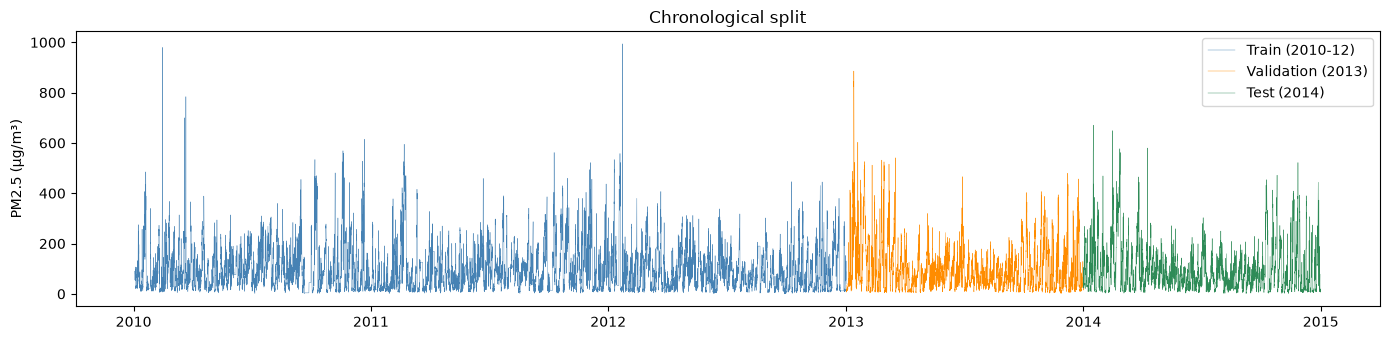

In [30]:
# Visual sanity check of the split
fig, ax = plt.subplots(figsize=(14, 3.5))
for part, name, color in [(train, 'Train (2010-12)', 'steelblue'), (val, 'Validation (2013)', 'darkorange'), (test, 'Test (2014)', 'seagreen')]:
    ax.plot(part['datetime'], part[TARGET], lw=0.3, color=color, label=name)
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_title('Chronological split'); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()